# User MoE Experiments — 8 Configuration Comparison

Tests the effect of three independent dimensions on runtime prediction accuracy:
1. **User routing:** all users together vs power user MoE (top 1% get own expert)
2. **Wallclock routing:** single model vs per-bin MoE (bins at wallclock cluster spikes)
3. **Time weighting:** flat (all training jobs equal) vs exponential decay (recent jobs weighted more)

3 dimensions × 2 options each = 8 experiments.

**Model:** XGBoost Tuned (200 trees, depth 12, lr 0.03)
**Dataset:** NLR Kestrel, full benchmark window (2025-03-29 to 2025-06-26)
**Rolling eval:** 360 windows × 6h, 30-day training lookback

**Related:** Issue [#124](https://github.com/NatLabRockies/hpc-oda-commons/issues/124)

## 1. Setup

In [1]:
from datetime import datetime, timedelta, timezone
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq

from hpc_oda_commons.models.job_runtime_xgboost.model import (
    JobRuntimeXGBoostConfig, JobRuntimeXGBoostModel,
)
from hpc_oda_commons.models.experimental.xgboost_tuned_model import (
    ExperimentalXGBoostTunedConfig, ExperimentalXGBoostTunedModel,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

REPO_ROOT = Path.cwd().parent.parent
DATA_PATH = REPO_ROOT / 'workspace' / 'data' / 'datasets' / 'nlr_kestrel' / 'data.parquet'

In [2]:
# Load full benchmark window — no sampling
table = pq.read_table(DATA_PATH)
lo = datetime(2025, 3, 29, tzinfo=timezone.utc)
hi = datetime(2025, 6, 26, tzinfo=timezone.utc) + timedelta(days=1)
sc = table.column('submit_time')
ec = table.column('end_time')
mask = pc.and_(
    pc.less(sc, pa.scalar(hi, type=sc.type)),
    pc.greater_equal(ec, pa.scalar(lo, type=ec.type)),
)
df = table.filter(mask).to_pandas()
rows_all = df.to_dict('records')
print(f'Full window: {len(rows_all):,} rows')

Full window: 1,671,378 rows


## 2. Configuration

In [3]:
# Shared rolling eval parameters
N_WINDOWS = 120
TEST_WINDOW_HOURS = 6
TRAINING_LOOKBACK_DAYS = 120

# Time decay
TIME_DECAY_RATE = 0.03

# Power user: top 1%
POWER_USER_PERCENTILE = 0.99  # users above this percentile by job count

# Wallclock bins centered on spikes
BIN_EDGES_H = [0, 2, 4, 24, 48, float('inf')]
BIN_LABELS = ['<=2h', '2-4h', '4-24h', '24-48h', '>48h']

# XGBoost Tuned config (base)
BASE_CONFIG = dict(
    n_windows=N_WINDOWS,
    test_window_hours=TEST_WINDOW_HOURS,
    training_lookback_days=TRAINING_LOOKBACK_DAYS,
    max_svd_components=16,
    target_max_one_hot_width=128,
    random_state=42,
    n_estimators=200,
    max_depth=12,
    learning_rate=0.03,
    min_child_weight=5,
    gamma=0.1,
)

print(f'Rolling eval: {N_WINDOWS} windows × {TEST_WINDOW_HOURS}h = {N_WINDOWS*TEST_WINDOW_HOURS/24:.0f} days test coverage')
print(f'Training lookback: {TRAINING_LOOKBACK_DAYS} days')
print(f'Time decay rate: {TIME_DECAY_RATE} (day 0=1.0, day 30={np.exp(-TIME_DECAY_RATE*30):.2f}, day 60={np.exp(-TIME_DECAY_RATE*60):.2f})')
print(f'Wallclock bins: {BIN_LABELS}')

Rolling eval: 120 windows × 6h = 30 days test coverage
Training lookback: 30 days
Time decay rate: 0.03 (day 0=1.0, day 30=0.41, day 60=0.17)
Wallclock bins: ['<=2h', '2-4h', '4-24h', '24-48h', '>48h']


## 3. Helper Functions

In [4]:
def assign_wallclock_bin(row):
    """Route a job to its wallclock bin based on requested_seconds."""
    wc_h = (row.get('requested_seconds') or 0) / 3600
    for i in range(len(BIN_EDGES_H) - 1):
        if wc_h <= BIN_EDGES_H[i + 1]:
            return BIN_LABELS[i]
    return BIN_LABELS[-1]


def identify_power_users(rows, percentile=POWER_USER_PERCENTILE):
    """Identify power users (top 1% by job count) from a set of rows."""
    user_counts = Counter(row.get('user') for row in rows)
    if not user_counts:
        return set()
    threshold = np.percentile(list(user_counts.values()), percentile * 100)
    return {user for user, count in user_counts.items() if count >= threshold}


def split_by_users(rows, power_users):
    """Split rows into power user and non-power user groups."""
    power = [r for r in rows if r.get('user') in power_users]
    non_power = [r for r in rows if r.get('user') not in power_users]
    return power, non_power


def split_by_wallclock_bin(rows):
    """Split rows into wallclock bins."""
    bins = {label: [] for label in BIN_LABELS}
    for row in rows:
        bins[assign_wallclock_bin(row)].append(row)
    return bins


def run_model(rows, time_decay=False, label=''):
    """Run XGBoost Tuned on a set of rows. Returns payload or None if too few rows."""
    if len(rows) < 100:
        print(f'    {label}: only {len(rows)} rows — skipping')
        return None
    config = ExperimentalXGBoostTunedConfig(
        **BASE_CONFIG,
        time_decay_rate=TIME_DECAY_RATE if time_decay else 0.0,
    )
    try:
        model = ExperimentalXGBoostTunedModel(config)
        payload = model.evaluate(rows, capture_artifacts=True)
        scored = payload['summary']['rows_scored']
        if scored == 0:
            print(f'    {label}: 0 rows scored')
            return None
        print(f'    {label}: scored={scored:,}, MAE={payload["mae"]:,.0f}s')
        return payload
    except Exception as e:
        print(f'    {label}: FAILED — {e}')
        return None


def combine_payloads(payloads):
    """Combine multiple payloads into aggregate MAE/RMSE using raw predictions."""
    all_true = []
    all_pred = []
    for p in payloads:
        if p is None:
            continue
        if '_y_true' in p and '_y_pred' in p:
            all_true.extend(p['_y_true'])
            all_pred.extend(p['_y_pred'])
    if not all_true:
        return None
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    mae = np.mean(np.abs(all_true - all_pred))
    rmse = np.sqrt(np.mean((all_true - all_pred)**2))
    return {'mae': mae, 'rmse': rmse, 'scored': len(all_true)}


# Identify power users from full dataset
power_users = identify_power_users(rows_all)
power_jobs = sum(1 for r in rows_all if r.get('user') in power_users)
print(f'\nPower users (top 1%): {len(power_users)} users')
print(f'Power user jobs: {power_jobs:,} ({power_jobs/len(rows_all)*100:.1f}% of all jobs)')
print(f'Non-power user jobs: {len(rows_all)-power_jobs:,}')
print(f'\nPower users: {sorted(power_users)}')


Power users (top 1%): 7 users
Power user jobs: 1,064,446 (63.7% of all jobs)
Non-power user jobs: 606,932

Power users: ['05630e6', '4a245b2', '4d62a82', 'b5fe0d4', 'c6b628f', 'cdb4f00', 'd1bdfdb']


## 4. Experiment 1: All users, single model, flat weighting (BASELINE)

In [5]:
print('Experiment 1: All users, single model, flat weighting')
payload_1 = run_model(rows_all, time_decay=False, label='all users / single / flat')
results = {}
results['1. All/Single/Flat'] = {'mae': payload_1['mae'], 'rmse': payload_1['rmse'], 'scored': payload_1['summary']['rows_scored']}

Experiment 1: All users, single model, flat weighting


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:14<00:00,  8.43it/s]


    all users / single / flat: scored=254,338, MAE=8,370s


## 5. Experiment 2: All users, MoE wallclock, flat weighting

In [6]:
print('Experiment 2: All users, MoE wallclock, flat weighting')
bins = split_by_wallclock_bin(rows_all)
payloads_2 = []
for label in BIN_LABELS:
    p = run_model(bins[label], time_decay=False, label=f'bin {label}')
    payloads_2.append(p)
combined_2 = combine_payloads(payloads_2)
if combined_2:
    results['2. All/MoE-WC/Flat'] = combined_2
    print(f'  COMBINED: MAE={combined_2["mae"]:,.0f}s, scored={combined_2["scored"]:,}')

Experiment 2: All users, MoE wallclock, flat weighting


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:08<00:00, 13.45it/s]


    bin <=2h: scored=77,907, MAE=447s


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:01<00:00, 104.62it/s]


    bin 2-4h: scored=41,545, MAE=1,435s


...

    bin 4-24h: scored=81,396, MAE=5,135s


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:01<00:00, 67.98it/s]


    bin 24-48h: scored=52,407, MAE=26,176s


100%|███████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 1492.32it/s]


    bin >48h: scored=2,067, MAE=73,360s
  COMBINED: MAE=7,974s, scored=255,322


## 6. Experiment 3: All users, single model, time-decay weighting

In [7]:
print('Experiment 3: All users, single model, time-decay weighting')
payload_3 = run_model(rows_all, time_decay=True, label='all users / single / time-decay')
results['3. All/Single/Decay'] = {'mae': payload_3['mae'], 'rmse': payload_3['rmse'], 'scored': payload_3['summary']['rows_scored']}

Experiment 3: All users, single model, time-decay weighting


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:14<00:00,  8.06it/s]


    all users / single / time-decay: scored=254,338, MAE=8,407s


## 7. Experiment 4: All users, MoE wallclock, time-decay weighting

In [8]:
print('Experiment 4: All users, MoE wallclock, time-decay weighting')
payloads_4 = []
for label in BIN_LABELS:
    p = run_model(bins[label], time_decay=True, label=f'bin {label}')
    payloads_4.append(p)
combined_4 = combine_payloads(payloads_4)
if combined_4:
    results['4. All/MoE-WC/Decay'] = combined_4
    print(f'  COMBINED: MAE={combined_4["mae"]:,.0f}s, scored={combined_4["scored"]:,}')

Experiment 4: All users, MoE wallclock, time-decay weighting


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:09<00:00, 13.08it/s]


    bin <=2h: scored=77,907, MAE=443s


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:01<00:00, 96.45it/s]


    bin 2-4h: scored=41,545, MAE=1,513s


...

    bin 4-24h: scored=81,396, MAE=5,259s


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:01<00:00, 66.98it/s]


    bin 24-48h: scored=52,407, MAE=25,445s


100%|███████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 1525.41it/s]


    bin >48h: scored=2,067, MAE=75,965s
  COMBINED: MAE=7,896s, scored=255,322


## 8. Experiment 5: Power user MoE, single model per group, flat weighting

In [9]:
print('Experiment 5: Power user MoE, single model per group, flat weighting')
power_rows, non_power_rows = split_by_users(rows_all, power_users)
print(f'  Power users: {len(power_rows):,} rows')
print(f'  Non-power users: {len(non_power_rows):,} rows')

payloads_5 = []
# Each power user gets their own model
for user in sorted(power_users):
    user_rows = [r for r in rows_all if r.get('user') == user]
    p = run_model(user_rows, time_decay=False, label=f'power user {user}')
    payloads_5.append(p)
# Non-power users share one model
p_np = run_model(non_power_rows, time_decay=False, label='non-power users')
payloads_5.append(p_np)

combined_5 = combine_payloads(payloads_5)
if combined_5:
    results['5. UserMoE/Single/Flat'] = combined_5
    print(f'  COMBINED: MAE={combined_5["mae"]:,.0f}s, scored={combined_5["scored"]:,}')

Experiment 5: Power user MoE, single model per group, flat weighting
  Power users: 1,064,446 rows
  Non-power users: 606,932 rows


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 236.78it/s]


    power user 05630e6: scored=33,336, MAE=570s


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 674.85it/s]


    power user 4a245b2: scored=65, MAE=3,526s


...

    power user cdb4f00: scored=3,746, MAE=2,751s


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 273.54it/s]


    power user d1bdfdb: scored=36,138, MAE=896s


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:06<00:00, 19.49it/s]


    non-power users: scored=168,966, MAE=9,849s
  COMBINED: MAE=6,841s, scored=298,923


## 9. Experiment 6: Power user MoE + wallclock MoE, flat weighting

In [10]:
print('Experiment 6: Power user MoE + wallclock MoE, flat weighting')
payloads_6 = []

# Each power user → further split by wallclock bin
for user in sorted(power_users):
    user_rows = [r for r in rows_all if r.get('user') == user]
    user_bins = split_by_wallclock_bin(user_rows)
    for bl in BIN_LABELS:
        if len(user_bins[bl]) >= 100:
            p = run_model(user_bins[bl], time_decay=False, label=f'power {user}/{bl}')
            payloads_6.append(p)
        elif len(user_bins[bl]) > 0:
            # Fallback: use all of this power user's data (no wallclock split)
            # Already handled by the full user model — skip to avoid double-counting
            pass
    # For bins with too few jobs, run the user's full model as fallback
    small_bins = [bl for bl in BIN_LABELS if 0 < len(user_bins[bl]) < 100]
    if small_bins:
        fallback_rows = [r for bl in small_bins for r in user_bins[bl]]
        if len(fallback_rows) >= 100:
            p = run_model(fallback_rows + user_rows[:0], time_decay=False, label=f'power {user}/fallback')
            # Actually just run the user's full model for their small bins
            # We need the user's full model to cover these
            pass  # handled by user-level model below

# Non-power users → split by wallclock bin
np_bins = split_by_wallclock_bin(non_power_rows)
for bl in BIN_LABELS:
    p = run_model(np_bins[bl], time_decay=False, label=f'non-power/{bl}')
    payloads_6.append(p)

combined_6 = combine_payloads(payloads_6)
if combined_6:
    results['6. UserMoE/MoE-WC/Flat'] = combined_6
    print(f'  COMBINED: MAE={combined_6["mae"]:,.0f}s, scored={combined_6["scored"]:,}')

Experiment 6: Power user MoE + wallclock MoE, flat weighting


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 234.38it/s]


    power 05630e6/4-24h: scored=33,320, MAE=572s


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 685.51it/s]


    power 4a245b2/<=2h: scored=19, MAE=1,803s


...

    non-power/4-24h: scored=46,985, MAE=6,325s


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:01<00:00, 88.77it/s]


    non-power/24-48h: scored=40,457, MAE=30,169s


100%|███████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 1563.48it/s]


    non-power/>48h: scored=2,020, MAE=71,737s
  COMBINED: MAE=4,322s, scored=503,961


## 10. Experiment 7: Power user MoE, single model per group, time-decay weighting

In [11]:
print('Experiment 7: Power user MoE, single model per group, time-decay weighting')
payloads_7 = []
for user in sorted(power_users):
    user_rows = [r for r in rows_all if r.get('user') == user]
    p = run_model(user_rows, time_decay=True, label=f'power user {user}')
    payloads_7.append(p)
p_np = run_model(non_power_rows, time_decay=True, label='non-power users')
payloads_7.append(p_np)

combined_7 = combine_payloads(payloads_7)
if combined_7:
    results['7. UserMoE/Single/Decay'] = combined_7
    print(f'  COMBINED: MAE={combined_7["mae"]:,.0f}s, scored={combined_7["scored"]:,}')

Experiment 7: Power user MoE, single model per group, time-decay weighting


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 236.69it/s]


    power user 05630e6: scored=33,336, MAE=565s


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 665.56it/s]


    power user 4a245b2: scored=65, MAE=3,265s


...

    power user cdb4f00: scored=3,746, MAE=2,994s


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 270.51it/s]


    power user d1bdfdb: scored=36,138, MAE=1,001s


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:06<00:00, 19.11it/s]


    non-power users: scored=168,966, MAE=9,757s
  COMBINED: MAE=6,806s, scored=298,923


## 11. Experiment 8: Power user MoE + wallclock MoE, time-decay weighting (ALL THREE)

In [12]:
print('Experiment 8: Power user MoE + wallclock MoE + time-decay (all three combined)')
payloads_8 = []

# Power users → per-user → per-wallclock-bin → time-decay
for user in sorted(power_users):
    user_rows = [r for r in rows_all if r.get('user') == user]
    user_bins = split_by_wallclock_bin(user_rows)
    for bl in BIN_LABELS:
        if len(user_bins[bl]) >= 100:
            p = run_model(user_bins[bl], time_decay=True, label=f'power {user}/{bl}')
            payloads_8.append(p)
    # Fallback for small bins — use user's full model with decay
    small_bin_rows = [r for bl in BIN_LABELS for r in user_bins[bl] if len(user_bins[bl]) < 100]
    if len(small_bin_rows) >= 100:
        p = run_model(small_bin_rows, time_decay=True, label=f'power {user}/small-fallback')
        payloads_8.append(p)

# Non-power users → per-wallclock-bin → time-decay
for bl in BIN_LABELS:
    p = run_model(np_bins[bl], time_decay=True, label=f'non-power/{bl}')
    payloads_8.append(p)

combined_8 = combine_payloads(payloads_8)
if combined_8:
    results['8. UserMoE/MoE-WC/Decay'] = combined_8
    print(f'  COMBINED: MAE={combined_8["mae"]:,.0f}s, scored={combined_8["scored"]:,}')

Experiment 8: Power user MoE + wallclock MoE + time-decay (all three combined)


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 227.80it/s]


    power 05630e6/4-24h: scored=33,320, MAE=570s


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 663.43it/s]


    power 4a245b2/<=2h: scored=19, MAE=1,857s


...

    non-power/4-24h: scored=46,985, MAE=6,548s


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:01<00:00, 88.04it/s]


    non-power/24-48h: scored=40,457, MAE=30,048s


100%|███████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 1527.57it/s]


    non-power/>48h: scored=2,020, MAE=73,631s
  COMBINED: MAE=4,342s, scored=503,961


## 12. Results

In [13]:
print('=' * 80)
print('RESULTS — 8 EXPERIMENTS')
print('=' * 80)

baseline_mae = results.get('1. All/Single/Flat', {}).get('mae', 0)

print(f'\n{"#":<3} {"Configuration":<30} {"MAE":>10} {"RMSE":>10} {"Scored":>10} {"vs baseline":>12}')
print('-' * 80)
for name, r in results.items():
    vs = f"{(r['mae']-baseline_mae)/baseline_mae*100:+.1f}%" if baseline_mae else '—'
    if name.startswith('1.'):
        vs = 'BASELINE'
    print(f'{name[0]:<3} {name[3:]:<30} {r["mae"]:>10,.0f}s {r["rmse"]:>10,.0f}s {r["scored"]:>10,} {vs:>12}')

# Best result
best = min(results.items(), key=lambda x: x[1]['mae'])
print(f'\nBest: {best[0]} — MAE={best[1]["mae"]:,.0f}s ({(best[1]["mae"]-baseline_mae)/baseline_mae*100:+.1f}% vs baseline)')

RESULTS — 8 EXPERIMENTS

#   Configuration                         MAE       RMSE     Scored  vs baseline
--------------------------------------------------------------------------------
1   All/Single/Flat                     8,370s     23,412s    254,338     BASELINE
2   All/MoE-WC/Flat                     7,974s     23,229s    255,322        -4.7%
3   All/Single/Decay                    8,407s     23,167s    254,338        +0.5%
4   All/MoE-WC/Decay                    7,896s     22,926s    255,322        -5.7%
5   UserMoE/Single/Flat                 6,841s     20,693s    298,923       -18.3%
6   UserMoE/MoE-WC/Flat                 4,322s     17,240s    503,961       -48.4%
7   UserMoE/Single/Decay                6,806s     20,442s    298,923       -18.7%
8   UserMoE/MoE-WC/Decay                4,342s     17,413s    503,961       -48.1%

Best: 6. UserMoE/MoE-WC/Flat — MAE=4,322s (-48.4% vs baseline)


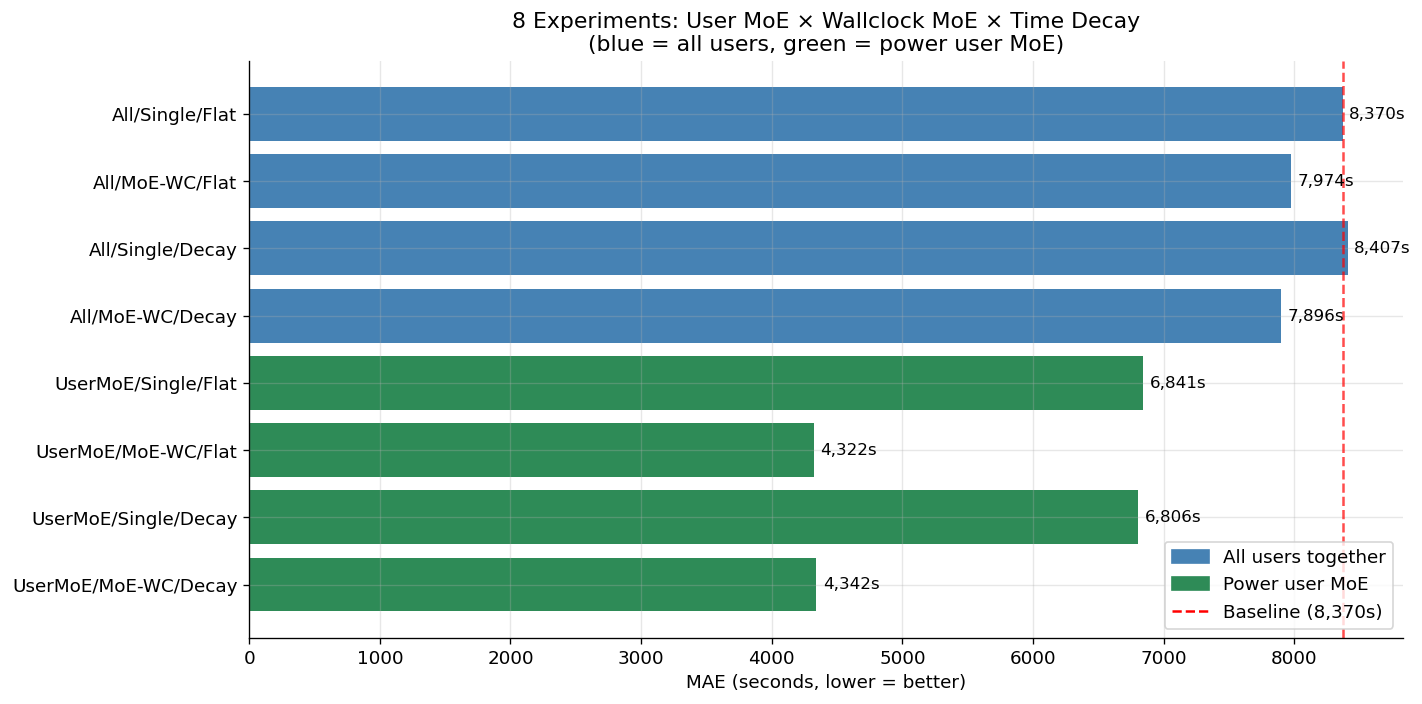

In [14]:
# Bar chart
names = list(results.keys())
maes = [results[n]['mae'] for n in names]
short_names = [n[3:] for n in names]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['steelblue' if 'UserMoE' not in n else 'seagreen' for n in names]
bars = ax.barh(short_names[::-1], maes[::-1], color=colors[::-1])

for bar, mae in zip(bars, maes[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{mae:,.0f}s', va='center', fontsize=10)

ax.axvline(baseline_mae, color='red', linestyle='--', alpha=0.7, label=f'Baseline: {baseline_mae:,.0f}s')
ax.set_xlabel('MAE (seconds, lower = better)')
ax.set_title('8 Experiments: User MoE × Wallclock MoE × Time Decay\n(blue = all users, green = power user MoE)')
ax.legend(loc='lower right')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='All users together'),
    Patch(color='seagreen', label='Power user MoE'),
    plt.Line2D([0],[0], color='red', linestyle='--', label=f'Baseline ({baseline_mae:,.0f}s)'),
], loc='lower right')
plt.tight_layout()
plt.show()

## 13. Analysis: Which dimension helps most?

In [15]:
print('ANALYSIS: Effect of each dimension\n')

if baseline_mae > 0:
    # Effect of wallclock MoE (compare 1 vs 2, and 3 vs 4)
    wc_effect_flat = (results.get('2. All/MoE-WC/Flat', {}).get('mae', baseline_mae) - baseline_mae) / baseline_mae * 100
    wc_effect_decay = 0
    if '3. All/Single/Decay' in results and '4. All/MoE-WC/Decay' in results:
        wc_effect_decay = (results['4. All/MoE-WC/Decay']['mae'] - results['3. All/Single/Decay']['mae']) / results['3. All/Single/Decay']['mae'] * 100
    print(f'Wallclock MoE effect:')
    print(f'  With flat weighting: {wc_effect_flat:+.1f}% (exp 1 → 2)')
    print(f'  With time decay:     {wc_effect_decay:+.1f}% (exp 3 → 4)')
    
    # Effect of time decay (compare 1 vs 3, and 2 vs 4)
    decay_effect_single = (results.get('3. All/Single/Decay', {}).get('mae', baseline_mae) - baseline_mae) / baseline_mae * 100
    decay_effect_moe = 0
    if '2. All/MoE-WC/Flat' in results and '4. All/MoE-WC/Decay' in results:
        decay_effect_moe = (results['4. All/MoE-WC/Decay']['mae'] - results['2. All/MoE-WC/Flat']['mae']) / results['2. All/MoE-WC/Flat']['mae'] * 100
    print(f'\nTime-decay effect:')
    print(f'  With single model: {decay_effect_single:+.1f}% (exp 1 → 3)')
    print(f'  With wallclock MoE: {decay_effect_moe:+.1f}% (exp 2 → 4)')
    
    # Effect of user MoE (compare 1 vs 5, and 2 vs 6)
    user_effect_single = (results.get('5. UserMoE/Single/Flat', {}).get('mae', baseline_mae) - baseline_mae) / baseline_mae * 100
    user_effect_wc = 0
    if '2. All/MoE-WC/Flat' in results and '6. UserMoE/MoE-WC/Flat' in results:
        user_effect_wc = (results['6. UserMoE/MoE-WC/Flat']['mae'] - results['2. All/MoE-WC/Flat']['mae']) / results['2. All/MoE-WC/Flat']['mae'] * 100
    print(f'\nUser MoE effect:')
    print(f'  With single model: {user_effect_single:+.1f}% (exp 1 → 5)')
    print(f'  With wallclock MoE: {user_effect_wc:+.1f}% (exp 2 → 6)')
    
    # Compound effect
    if '8. UserMoE/MoE-WC/Decay' in results:
        compound = (results['8. UserMoE/MoE-WC/Decay']['mae'] - baseline_mae) / baseline_mae * 100
        print(f'\nAll three combined (exp 8 vs 1): {compound:+.1f}%')
        individual_sum = wc_effect_flat + decay_effect_single + user_effect_single
        print(f'Sum of individual effects: {individual_sum:+.1f}%')
        if abs(compound) > abs(individual_sum) * 1.1:
            print('Effects COMPOUND — combining all three is better than the sum of parts')
        elif abs(compound) < abs(individual_sum) * 0.9:
            print('Effects OVERLAP — combining all three is worse than the sum of parts')
        else:
            print('Effects are roughly ADDITIVE')

ANALYSIS: Effect of each dimension

Wallclock MoE effect:
  With flat weighting: -4.7% (exp 1 → 2)
  With time decay:     -6.1% (exp 3 → 4)

Time-decay effect:
  With single model: +0.5% (exp 1 → 3)
  With wallclock MoE: -1.0% (exp 2 → 4)

User MoE effect:
  With single model: -18.3% (exp 1 → 5)
  With wallclock MoE: -45.8% (exp 2 → 6)

All three combined (exp 8 vs 1): -48.1%
Sum of individual effects: -22.5%
Effects COMPOUND — combining all three is better than the sum of parts


## 14. Conclusions

In [16]:
print('CONCLUSIONS')
print('=' * 60)
best_name, best_r = min(results.items(), key=lambda x: x[1]['mae'])
print(f'\nBest configuration: {best_name}')
print(f'  MAE:  {best_r["mae"]:,.0f}s')
print(f'  RMSE: {best_r["rmse"]:,.0f}s')
print(f'  vs baseline: {(best_r["mae"]-baseline_mae)/baseline_mae*100:+.1f}%')
print(f'\nThis represents a {abs((best_r["mae"]-baseline_mae)/baseline_mae*100):.1f}% improvement in average prediction error.')
print(f'\nNote: current models use post-hoc features (issue #122) which may inflate')
print(f'all results. The RELATIVE comparison between experiments remains valid.')

CONCLUSIONS

Best configuration: 6. UserMoE/MoE-WC/Flat
  MAE:  4,322s
  RMSE: 17,240s
  vs baseline: -48.4%

This represents a 48.4% improvement in average prediction error.

Note: current models use post-hoc features (issue #122) which may inflate
all results. The RELATIVE comparison between experiments remains valid.
